In [2]:
print('Hie!, WAssUppp')

Hie!, WAssUppp


# Pandas Explode

Load data.

In [3]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

c:\Users\KAIF FIROZ\anaconda3\envs\kaifs_python_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Example

#### Why `df.explode()` is needed?

Here's a fake dataset of 3 job postings.

In [9]:
data = {
'job_title_short': ['Data Analyst', 'Data Scientist', 'Data Engineer'],
'job_skills': [['excel', 'sql', 'python'], ['python', 'r'], ['aws', 'python', 'airflow']]
}

df_skills = pd.DataFrame(data)

df_skills

,job_title_short,job_skills
0,Data Analyst,"[excel, sql, python]"
1,Data Scientist,"[python, r]"
2,Data Engineer,"[aws, python, airflow]"


If we wanted to analyze the skills in this we'd need a minimum of 5 lines of code to get the counts of skills.

In [5]:
df_skill_lists = df_skills.copy()

for row in df_skill_lists.itertuples():
    for skill in row.job_skills:
        df_skill_lists[skill] = df_skill_lists['job_skills'].apply(lambda x: skill in x)
        df_skill_lists[skill] = df_skill_lists[skill].astype(int)
        
df_skill_lists.loc['Total'] = df_skill_lists.sum()
    
df_skill_lists.iloc[:, 2:]

,excel,sql,python,r,aws,airflow
0,1,1,1,0,0,0
1,0,0,1,1,0,0
2,0,0,1,0,1,1
Total,1,1,3,1,1,1


However, exploding it out makes the data a lot easier to work with.

In [6]:
df_exploded = df_skills.explode('job_skills')

df_exploded

,job_title_short,job_skills
0,Data Analyst,excel
0,Data Analyst,sql
0,Data Analyst,python
1,Data Scientist,python
1,Data Scientist,r
2,Data Engineer,aws
2,Data Engineer,python
2,Data Engineer,airflow


In [7]:
df_exploded.value_counts('job_skills')

job_skills
python     3
airflow    1
aws        1
excel      1
r          1
sql        1
Name: count, dtype: int64

<Axes: xlabel='job_skills'>

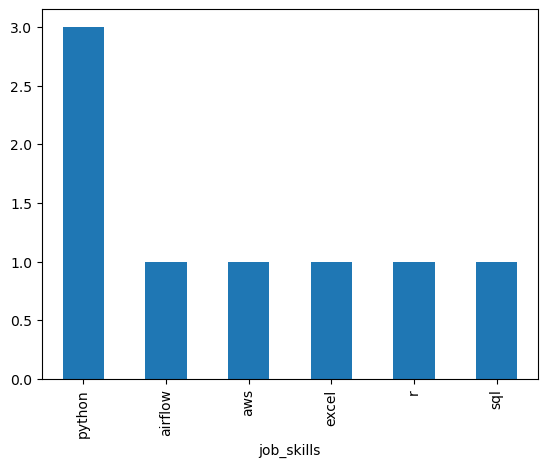

In [8]:
df_exploded.value_counts('job_skills').plot(kind='bar')

## **Load the Data**

In [10]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [14]:
df[['job_title_short', 'job_skills']].head(5)

,job_title_short,job_skills
0,Senior Data Engineer,None
1,Data Analyst,"[r, python, sql, nosql, power bi, tableau]"
2,Data Engineer,"[python, sql, c#, azure, airflow, dax, docker,..."
3,Data Engineer,"[python, c++, java, matlab, aws, tensorflow, k..."
4,Data Engineer,"[bash, python, oracle, aws, ansible, puppet, j..."


In [16]:
df_exploded_on_skills = df.explode('job_skills')

<Axes: xlabel='job_skills'>

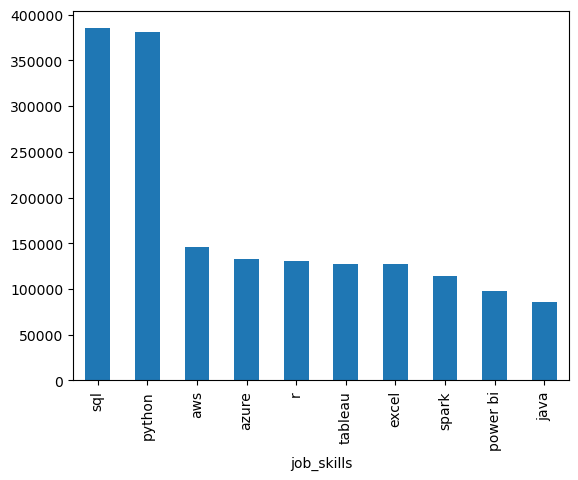

In [20]:
df_exploded_on_skills['job_skills'].value_counts().head(10).plot(kind= 'bar')

In [25]:
skills_count = df_exploded_on_skills.groupby(['job_title_short','job_skills']).size()

In [26]:
type(skills_count)

pandas.core.series.Series

In [31]:
df_skills_count = skills_count.reset_index(name='Count_of_job')

df_skills_count = df_skills_count.sort_values(by='Count_of_job',ascending= False)

df_skills_count

,job_title_short,job_skills,Count_of_job
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


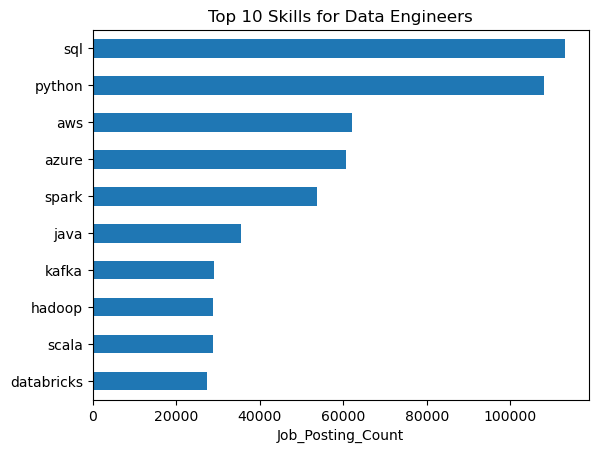

In [ ]:
job_title = 'Data Analyst'
top_skills = 10  

# job_title = input("Enter job title: ")
#                                             # We can also use it as a input method.
# top_skills = int(input("Enter how many top skills you want: "))


df_skkill_final = df_skills_count[df_skills_count['job_title_short'] == job_title].head(top_skills)

df_skkill_final.plot(kind=  'barh', x= 'job_skills', y= 'Count_of_job')
plt.gca().invert_yaxis()
plt.title(f'Top {top_skills} Skills for {job_title}s')
plt.xlabel('Job_Posting_Count')
plt.ylabel('')
plt.legend().set_visible(False)
plt.show()